In [ ]:
import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt
import src.gymnasium_envs.convex_optimization_env
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from src.optimization.convex_function import ConvexFunction
from src.optimization.optimization_methods import gradient_descent_optimizer, adam_optimizer

seed = 100

This notebook is dedicated to a two-dimensional convex optimization problem with an adaptive learning rate. 

In it, we will check that our RL algorithm learns to be better than GD and ADAM.

At first we'll use RL optimization with learned LR

In [ ]:
env = make_vec_env(
    "convex_optimization_env/ConvexOptimization-v0",
    n_envs=1,
    seed=seed,
    env_kwargs={
        "render_mode": "ansi",
        "in_features": 2
    }
)

env = VecNormalize.load("../2d_convex_optimization_vec_normalize_stats.pkl", env)

env.training = False
env.norm_reward = False 

model = PPO.load("../2d_convex_optimization", env=env, seed=seed)

obs = env.reset()

x0 = env.envs[0].unwrapped.get_x_start()

func = env.envs[0].unwrapped.get_function()

rl_gd_info = [[{
    'iteration': 0, 
    'function_value': func(x0), 
    'x': x0.copy()
}]]

AttributeError: 'ConvexOptimization' object has no attribute 'get_function'

In [ ]:
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, terminated, info = env.step(action)

    print(info)
    
    rl_gd_info.append(info)

    done = terminated

[{'iteration': 1, 'function_value': 2.3229010064588187, 'grad_norm': np.float64(2.5445751155718233), 'grad_delta_norm': np.float64(0.04381329535353843), 'x': array([0.65375561, 0.19756198]), 'status': '', 'TimeLimit.truncated': False}]
[{'iteration': 2, 'function_value': 2.2911734698858197, 'grad_norm': np.float64(2.5128304851951744), 'grad_delta_norm': np.float64(0.032641396899100526), 'x': array([0.64167048, 0.2009349 ]), 'status': '', 'TimeLimit.truncated': False}]
[{'iteration': 3, 'function_value': 2.2602274682044072, 'grad_norm': np.float64(2.4815216326317575), 'grad_delta_norm': np.float64(0.032191854091242186), 'x': array([0.62974428, 0.20430212]), 'status': '', 'TimeLimit.truncated': False}]
[{'iteration': 4, 'function_value': 2.2300424706049746, 'grad_norm': np.float64(2.450641627355873), 'grad_delta_norm': np.float64(0.03174941022809978), 'x': array([0.61797472, 0.20766326]), 'status': '', 'TimeLimit.truncated': False}]
[{'iteration': 5, 'function_value': 2.200598880670057, 

Now using default gradient methods

In [ ]:
function1 = ConvexFunction(in_features=2, random_state=seed)

gd_info = []
adam_info = []

gradient_descent_optimizer(function1, x0=x0, opt_info=gd_info)
adam_optimizer(function1, x0=x0, opt_info=adam_info)

OptimizeResult(iteration_count=2030, x_start=array([0.66996326, 0.19310805]), x_best=array([-0.30574494,  0.68693176]), function_value=0.9792065821481406, grad_norm=np.float64(0.0010202072858848665), grad_delta_norm=np.float64(3.0311083821221643e-05), status=1)

Let's visualize any gradient descent

In [ ]:
function1(x0)

2.3660293567266293

In [ ]:
gd_it, gd_val = zip(*[(item['iteration'], item['function_value']) for item in gd_info])
adam_it, adam_val = zip(*[(item['iteration'], item['function_value']) for item in adam_info])
rl_gd_it, rl_gd_val = zip(*[(item[0]['iteration'], item[0]['function_value']) for item in rl_gd_info[:-2]])

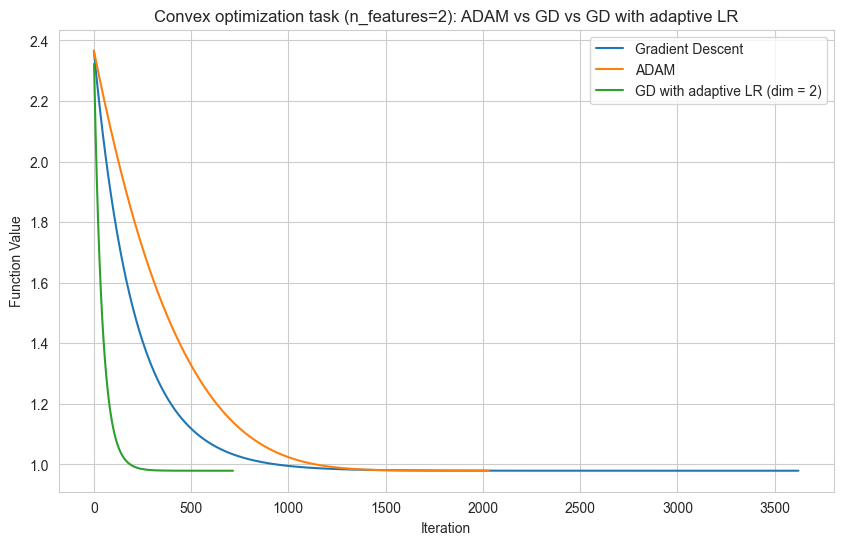

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(x=gd_it, y=gd_val, label='Gradient Descent')
sns.lineplot(x=adam_it, y=adam_val, label='ADAM')
sns.lineplot(x=rl_gd_it, y=rl_gd_val, label='GD with adaptive LR (dim = 2)')

plt.title('Convex optimization task (n_features=2): ADAM vs GD vs GD with adaptive LR')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.legend()
plt.show()